# Posture Detection V2 — 09 Upper-Body Model Retraining

Retrains the MultiPosture classifier with only webcam-reliable upper-body landmarks. It compares the original 99-coordinate model against a reduced 57-coordinate model using the **same participant-independent split**, then saves the reduced model and a strict feature/OOD contract for webcam integration.

The 19 retained landmarks are MediaPipe indices **0–16 plus both hips (23–24)**. Knees, ankles, heels, feet, and detailed finger landmarks are excluded.


## 1. Setup and dataset

Run Notebook 07 first if `data/public_multiposture/data.csv` is not already present. This cell can also download the published CSV directly.


In [1]:
# Uncomment if needed: %pip install -q scikit-learn joblib seaborn
import hashlib, json, re, time, urllib.request
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit

wd=Path.cwd()
ROOT=wd.parent if wd.name=='notebooks' else wd if wd.name=='project_v2' else wd/'project_v2'
DATA_DIR=ROOT/'data'/'public_multiposture'
RESULT_DIR=ROOT/'results'/'multiposture_upper57'
MODEL_DIR=ROOT/'models'
for d in (DATA_DIR,RESULT_DIR,MODEL_DIR): d.mkdir(parents=True,exist_ok=True)

DOI='10.5281/zenodo.14230872'
URL='https://zenodo.org/records/14230872/files/data.csv?download=1'
CSV=DATA_DIR/'data.csv'
if not CSV.exists(): urllib.request.urlretrieve(URL,CSV)
digest=hashlib.md5(CSV.read_bytes()).hexdigest()
print('Project root:',ROOT.resolve())
print('Dataset:',CSV.resolve(),'MB:',round(CSV.stat().st_size/1e6,2),'MD5:',digest)
if digest!='7efbc94d653acf32eefecec3ff26d6c6':
    print('WARNING: checksum differs from the published Zenodo record.')


Project root: C:\Users\manth\Desktop\project_v2
Dataset: C:\Users\manth\Desktop\project_v2\data\public_multiposture\data.csv MB: 9.33 MD5: 7efbc94d653acf32eefecec3ff26d6c6


## 2. Schema, labels, and 57-feature contract

The dataset is already hip-centered. We preserve its coordinate convention and select the same named coordinates that the webcam adapter will produce.


In [2]:
data=pd.read_csv(CSV)
data.columns=[str(c).strip() for c in data.columns]

def choose(patterns,columns):
    for pattern in patterns:
        hits=[c for c in columns if re.search(pattern,c,re.I)]
        if hits: return hits[0]
    return None

UPPER_LABEL=choose([r'upper.*(label|posture|class)',r'(label|posture|class).*upper',r'^upper$',r'^label_?1$'],data.columns)
PARTICIPANT=choose([r'participant',r'subject',r'person',r'user'],data.columns)
if UPPER_LABEL is None or PARTICIPANT is None:
    raise ValueError(f'Could not detect label/participant columns: label={UPPER_LABEL}, participant={PARTICIPANT}')

LANDMARK_NAMES=['nose','left_eye_inner','left_eye','left_eye_outer','right_eye_inner','right_eye','right_eye_outer',
                'left_ear','right_ear','mouth_left','mouth_right','left_shoulder','right_shoulder',
                'left_elbow','right_elbow','left_wrist','right_wrist','left_pinky','right_pinky',
                'left_index','right_index','left_thumb','right_thumb','left_hip','right_hip',
                'left_knee','right_knee','left_ankle','right_ankle','left_heel','right_heel',
                'left_foot_index','right_foot_index']
KEEP_INDICES=list(range(17))+[23,24]
KEEP_LANDMARKS=[LANDMARK_NAMES[i] for i in KEEP_INDICES]
FEATURES_57=[f'{name}_{axis}' for name in KEEP_LANDMARKS for axis in 'xyz']
FEATURES_99=[f'{name}_{axis}' for name in LANDMARK_NAMES for axis in 'xyz']
missing=[c for c in FEATURES_99 if c not in data.columns]
if missing: raise ValueError(f'Dataset is missing expected MediaPipe columns: {missing[:10]}')

LABEL_MAP={'TUP':'upright','TLB':'lean_backward','TLF':'lean_forward','TLR':'lean_right','TLL':'lean_left'}
y_all=data[UPPER_LABEL].astype(str).str.strip().str.upper().map(LABEL_MAP)
numeric=data[FEATURES_99].replace([np.inf,-np.inf],np.nan)
usable=y_all.notna() & numeric.notna().all(axis=1) & data[PARTICIPANT].notna()
X99=numeric.loc[usable].astype(np.float32)
X57=X99[FEATURES_57].copy()
y=y_all.loc[usable]
groups=data.loc[usable,PARTICIPANT].astype(str)

print('Rows:',len(X57),'Participants:',groups.nunique())
print('Original features:',X99.shape[1],'Reduced features:',X57.shape[1])
print('Retained landmarks:',KEEP_LANDMARKS)
display(y.value_counts().to_frame('frames'))
assert X57.shape[1]==57 and groups.nunique()>=3


Rows: 4794 Participants: 13
Original features: 99 Reduced features: 57
Retained landmarks: ['nose', 'left_eye_inner', 'left_eye', 'left_eye_outer', 'right_eye_inner', 'right_eye', 'right_eye_outer', 'left_ear', 'right_ear', 'mouth_left', 'mouth_right', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'left_hip', 'right_hip']


,frames
upperbody_label,
lean_forward,1897
upright,1615
lean_backward,442
lean_left,420
lean_right,420


## 3. Identical participant-independent split

No participant appears in more than one split. Random states 42 and 43 match Notebook 07.


In [3]:
outer=GroupShuffleSplit(n_splits=1,test_size=.20,random_state=42)
trainval_i,test_i=next(outer.split(X57,y,groups))
g_tv=groups.iloc[trainval_i]
inner=GroupShuffleSplit(n_splits=1,test_size=.20,random_state=43)
train_i,val_i=next(inner.split(X57.iloc[trainval_i],y.iloc[trainval_i],g_tv))

train_idx=np.asarray(trainval_i)[train_i]
val_idx=np.asarray(trainval_i)[val_i]
test_idx=np.asarray(test_i)

train_groups=set(groups.iloc[train_idx]); val_groups=set(groups.iloc[val_idx]); test_groups=set(groups.iloc[test_idx])
assert train_groups.isdisjoint(val_groups) and train_groups.isdisjoint(test_groups) and val_groups.isdisjoint(test_groups)

split_table=pd.DataFrame({
    'split':['train','validation','test'],
    'rows':[len(train_idx),len(val_idx),len(test_idx)],
    'participants':[len(train_groups),len(val_groups),len(test_groups)],
    'participant_ids':[sorted(train_groups),sorted(val_groups),sorted(test_groups)]
})
display(split_table)


,split,rows,participants,participant_ids
0,train,2964,8,"[10, 11, 12, 2, 3, 4, 5, 7]"
1,validation,540,2,"[13, 9]"
2,test,1290,3,"[1, 6, 8]"


## 4. Fair 99-feature versus 57-feature comparison

Both models use identical hyperparameters and rows. Validation is inspected first; the untouched test split is evaluated only after the configuration is fixed.


In [4]:
def new_model():
    return RandomForestClassifier(n_estimators=500,class_weight='balanced_subsample',min_samples_leaf=2,
                                  max_features='sqrt',n_jobs=-1,random_state=42)

models={}
comparison=[]
for name,X in [('full_99',X99),('upper_57',X57)]:
    model=new_model()
    started=time.perf_counter()
    model.fit(X.iloc[train_idx],y.iloc[train_idx])
    val_pred=model.predict(X.iloc[val_idx])
    val_f1=f1_score(y.iloc[val_idx],val_pred,average='macro')
    model.fit(X.iloc[np.r_[train_idx,val_idx]],y.iloc[np.r_[train_idx,val_idx]])
    test_pred=model.predict(X.iloc[test_idx])
    elapsed=time.perf_counter()-started
    metrics={'model':name,'features':X.shape[1],
             'validation_macro_f1':float(val_f1),
             'test_accuracy':float(accuracy_score(y.iloc[test_idx],test_pred)),
             'test_macro_f1':float(f1_score(y.iloc[test_idx],test_pred,average='macro')),
             'test_weighted_f1':float(f1_score(y.iloc[test_idx],test_pred,average='weighted')),
             'training_seconds':float(elapsed)}
    comparison.append(metrics)
    models[name]=(model,test_pred)

comparison=pd.DataFrame(comparison)
display(comparison)
comparison.to_csv(RESULT_DIR/'model_comparison.csv',index=False)


,model,features,validation_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,training_seconds
0,full_99,99,0.965593,0.963566,0.943817,0.962770,8.056221
1,upper_57,57,0.971071,0.965116,0.943366,0.964252,8.242988


## 5. Reduced-model diagnostics

Review per-class recall—especially `lean_backward`—before webcam integration.


               precision    recall  f1-score   support

      upright     0.9327    0.9823    0.9568       395
lean_backward     0.9592    0.7231    0.8246        65
 lean_forward     0.9748    0.9831    0.9789       590
   lean_right     1.0000    1.0000    1.0000       120
    lean_left     1.0000    0.9167    0.9565       120

     accuracy                         0.9651      1290
    macro avg     0.9733    0.9210    0.9434      1290
 weighted avg     0.9658    0.9651    0.9643      1290



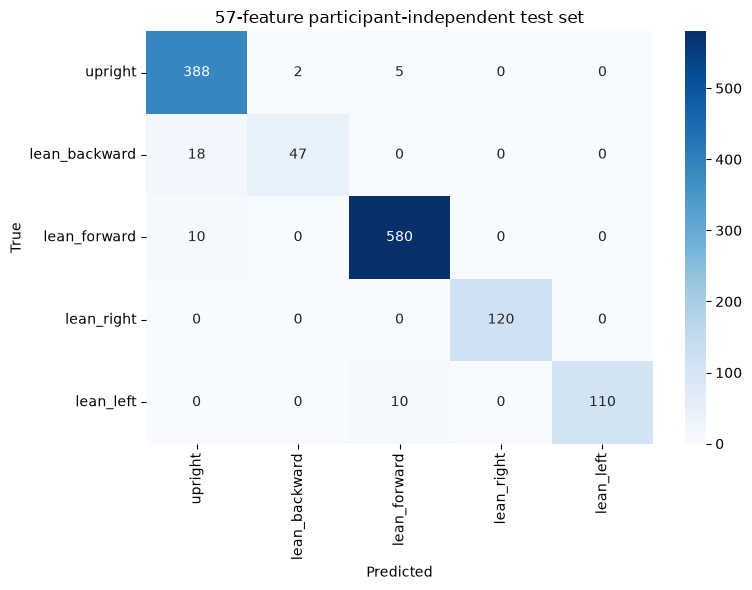

,importance
left_shoulder_x,0.064560
right_shoulder_x,0.056289
left_shoulder_z,0.055388
right_ear_x,0.054975
right_shoulder_z,0.050299
left_ear_x,0.050146
mouth_right_z,0.047373
mouth_left_z,0.043328
left_ear_z,0.041207
left_eye_inner_x,0.033247


In [5]:
model,test_pred=models['upper_57']
truth=y.iloc[test_idx]
order=list(LABEL_MAP.values())
print(classification_report(truth,test_pred,labels=order,digits=4,zero_division=0))

cm=confusion_matrix(truth,test_pred,labels=order)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=order,yticklabels=order,cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('57-feature participant-independent test set')
plt.tight_layout(); plt.show()

importance=pd.Series(model.feature_importances_,index=FEATURES_57).sort_values(ascending=False)
display(importance.head(20).to_frame('importance'))


## 6. OOD calibration and artifact saving

OOD limits are fitted from **training + validation only**, never from the test participants. Notebook 10 will use these exact saved limits rather than recomputing them differently.


In [6]:
fit_idx=np.r_[train_idx,val_idx]
reference=X57.iloc[fit_idx]
lower=reference.quantile(.005)
upper=reference.quantile(.995)

MODEL_FILE=MODEL_DIR/'multiposture_upper57_rf.joblib'
CONTRACT_FILE=MODEL_DIR/'multiposture_upper57_contract.json'
joblib.dump(model,MODEL_FILE)

reduced_metrics=comparison.set_index('model').loc['upper_57'].to_dict()
contract={
    'contract_version':2,
    'created_utc':datetime.now(timezone.utc).isoformat(),
    'source_doi':DOI,'source_url':URL,'source_md5':digest,
    'participant_column':PARTICIPANT,'upper_label_column':UPPER_LABEL,
    'landmark_indices':KEEP_INDICES,'landmark_names':KEEP_LANDMARKS,
    'feature_columns':FEATURES_57,'coordinate_transform':'subtract midpoint of MediaPipe hips (23,24)',
    'ood_lower_quantile':0.005,'ood_upper_quantile':0.995,
    'ood_lower':{k:float(v) for k,v in lower.items()},
    'ood_upper':{k:float(v) for k,v in upper.items()},
    'maximum_ood_fraction':0.20,'minimum_probability':0.55,
    'classes':list(model.classes_),'label_map':LABEL_MAP,
    'split_unit':'participant','split_random_states':[42,43],
    'test_metrics':reduced_metrics,
    'limitations':['Public skeleton coordinates and live MediaPipe coordinates may still have domain shift.',
                   'No public raw videos are included for camera-pipeline matching.',
                   'Webcam trust coverage must be measured before enabling learned labels.']
}
CONTRACT_FILE.write_text(json.dumps(contract,indent=2),encoding='utf-8')

predictions=pd.DataFrame({'true':truth.to_numpy(),'predicted':test_pred,
                          'participant':groups.iloc[test_idx].to_numpy()})
predictions.to_csv(RESULT_DIR/'test_predictions_upper57.csv',index=False)
split_table.to_csv(RESULT_DIR/'participant_split_summary.csv',index=False)
importance.rename('importance').to_csv(RESULT_DIR/'feature_importance.csv')

print('Saved model:',MODEL_FILE.resolve())
print('Saved contract:',CONTRACT_FILE.resolve())
print('Saved results:',RESULT_DIR.resolve())
print('Notebook 10 should load the upper57 model and contract—not overwrite Notebook 08 yet.')


Saved model: C:\Users\manth\Desktop\project_v2\models\multiposture_upper57_rf.joblib
Saved contract: C:\Users\manth\Desktop\project_v2\models\multiposture_upper57_contract.json
Saved results: C:\Users\manth\Desktop\project_v2\results\multiposture_upper57
Notebook 10 should load the upper57 model and contract—not overwrite Notebook 08 yet.


## What to send back

After running all cells, send the notebook with outputs. We will verify:

1. the 57-feature validation/test macro-F1 versus the 99-feature baseline;
2. per-class recall, particularly `lean_backward`;
3. the saved model and contract paths;
4. then build Notebook 10 to integrate the reduced model into the hybrid webcam safely.
